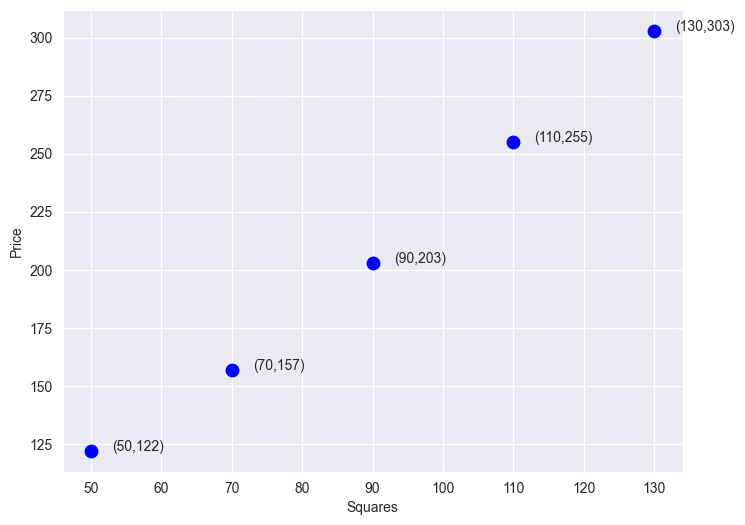

In [2]:
'''单元1'''
import matplotlib.pyplot as plt
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib.lines import lineStyles
from matplotlib.widgets import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sympy.abc import alpha
from sympy.physics.units import current, degree
from werkzeug.debug.repr import missing

# 1、准备数据
square = [50, 70, 90, 110, 130]     # 面积
price = [122, 157, 203, 255, 303]   # 价格

# 2、创建图表
plt.figure(figsize=(8, 6))
plt.scatter(square, price, color='blue', s=80)

# 3、设置坐标轴
plt.xlabel('Squares')
plt.ylabel('Price')

# 4、标注与显示
for a, p in zip(square, price):
    plt.text(a+3, p, f'({a},{p})')

# 5、显示结果
plt.grid(True)
plt.show()

In [3]:
'''单元2'''
import numpy as np
from sklearn.linear_model import LinearRegression

# 1、数据
x = np.array([
    [50, 3, 0.5, 5],
    [70, 15, 1.2, 10],
    [90, 8, 0.3, 2],
    [110, 20, 2.0, 15],
    [130, 12, 0.8, 8]
])
y = np.array([180, 210, 320, 280, 380])

# 2、训练模型
model = LinearRegression()
model.fit(x, y)

# 3、查看学到的权重
feature_names = ['面积', '楼层', '距离地铁', '房龄']
print("各特征权重")
for name, w in zip(feature_names, model.coef_):
    print(f"    {name}: {w:+.2f}")
print(f"    偏置 b: {model.intercept_:.2f}")

# 4、预测新数据，100平米，10楼，距离地铁0.6km，房龄5年
new_house = np.array([[100, 10, 0.6, 5]])
pred = model.predict(new_house)
print(f"预测房价：{pred[0]:.1f} 万元")

各特征权重
    面积: +2.63
    楼层: +1.77
    距离地铁: -1.23
    房龄: -8.60
    偏置 b: 86.91
预测房价：323.7 万元


In [3]:
'''单元3'''
import numpy as np

# 1、生成数据集
np.random.seed(42)
n_samples = 100
square_m2 = np.random.uniform(90, 150, n_samples)
squares = square_m2 / 100  # 单位：百平方米
price = 250 * squares + 30 + np.random.randn(n_samples) * 15

print(f"房屋数量：{len(squares)}（套）")
print(f"面积范围：{square_m2.min():.1f} - {square_m2.max():.1f}（平米）")
print(f"价格范围：{price.min():.1f} - {price.max():.1f}（万）")
print(f"真实规律：房价(万) = 2.5 * 面积(平米) + 30")
print("==========================================")

# 2、梯度下降函数（修复缩进）
def gradient_descent(X, y, lr = 0.1, epochs = 200):
    # 初始化参数
    w, b = 0.0, 0.0
    n = len(X)

    # 记录历史
    history = {'w': [w], 'b': [b], 'loss': [np.mean((w*X + b - y)**2)]}

    # 迭代训练
    for epoch in range(epochs):
        y_pred = w * X + b
        # 梯度计算
        dw = (2 / n) * np.sum((y_pred - y) * X)
        db = (2 / n) * np.sum(y_pred - y)
        # 更新参数
        w -= lr * dw
        b -= lr * db
        # 记录损失与参数
        current_loss = np.mean((w*X + b - y)**2)
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(current_loss)

        # 每隔 1% 轮次打印进度，改用整数整除避免浮点问题
        print_interval = epochs // 100
        if epoch % print_interval == 0:
            print(f"迭代 {epoch:5d}: w={w:.2f}, b={b:.2f}, loss={current_loss:.2f}")

    return history

# 调用梯度下降
history = gradient_descent(squares, price, lr = 0.01, epochs=100000)
# 输出最终拟合公式
final_w = history['w'][-1]
final_b = history['b'][-1]
print(f"\n拟合结果：房价(万) = {final_w/100:.3f} * 面积(平米) + {final_b:.2f}")
print(f"对应百平米单位公式：房价(万) = {final_w:.2f} * 面积(百平米) + {final_b:.2f}\n")

# 使用 Adam 优化器加速
def adam_optimizer(X, y, lr=0.1, epochs=200, beta1=0.9, beta2=0.999, epsilon=1e-8):
    # 初始化参数
    w, b = 0.0, 0.0
    n = len(X)

    # Adam 特有的状态变量初始化
    m_w, v_w = 0.0, 0.0 # w 的一阶矩和二阶矩
    m_b, v_b = 0.0, 0.0 # b 的一阶矩和二阶矩

    # 初始化历史记录
    history = {'w': [w], 'b': [b], 'loss': [np.mean((w*X+b-y)**2)]}

    # 进行迭代训练
    for epoch in range(epochs):
        t = epoch + 1 # Adam 的时间步从 1 开始，用于偏差校正

        # 1、计算当前预测值
        y_pred = w * X + b

        # 2、计算当前梯度
        dw = (2/n) * np.sum((y_pred - y) * X)
        db = (2/n) * np.sum(y_pred - y)

        # 3、更新一阶矩（动量：累积历史梯度方向）
        m_w = beta1 * m_w + (1 - beta1) * dw
        m_b = beta1 * m_b + (1 - beta1) * db

        # 4、更新二阶矩（RMSProp：累积历史梯度平方）
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        v_b = beta2 * v_b + (1 - beta2) * (db**2)

        # 5、计算偏差校正后的一阶、二阶矩
        m_w_hat = m_w / (1 - beta1**t)
        m_b_hat = m_b / (1 - beta1**t)
        v_w_hat = v_w / (1 - beta2**t)
        v_b_hat = v_b / (1 - beta2**t)

        # 6、使用 Adam 公式更新参数
        w -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
        b -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

        # 计算当前 loss
        current_loss = np.mean((w*X+b-y)**2)

        # 记录参数和损失
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(current_loss)

        # 每隔 1% 轮次，打印一次进度
        print_step = max(1, int(epochs/100))
        if epoch % print_step == 0:
            print(f"迭代 {epoch:5d}: w={w:.4f}, loss={current_loss:.4f}")

    return history

history = adam_optimizer(squares, price, lr=0.1, epochs=50000)
print(f"\n最终结果：房价 = {history['w'][-1]/100:.3f} * 面积（平米）+ {history['b'][-1]:.2f}")

房屋数量：100（套）
面积范围：90.3 - 149.2（平米）
价格范围：248.0 - 414.8（万）
真实规律：房价(万) = 2.5 * 面积(平米) + 30
迭代     0: w=7.85, b=6.51, loss=97789.54
迭代  1000: w=179.58, b=114.15, loss=291.85
迭代  2000: w=193.12, b=97.93, loss=246.94
迭代  3000: w=203.55, b=85.43, loss=220.31
迭代  4000: w=211.59, b=75.81, loss=204.51
迭代  5000: w=217.77, b=68.40, loss=195.14
迭代  6000: w=222.54, b=62.70, loss=189.58
迭代  7000: w=226.21, b=58.30, loss=186.29
迭代  8000: w=229.04, b=54.91, loss=184.33
迭代  9000: w=231.21, b=52.31, loss=183.17
迭代 10000: w=232.89, b=50.30, loss=182.48
迭代 11000: w=234.18, b=48.75, loss=182.08
迭代 12000: w=235.17, b=47.56, loss=181.83
迭代 13000: w=235.94, b=46.65, loss=181.69
迭代 14000: w=236.53, b=45.94, loss=181.61
迭代 15000: w=236.98, b=45.39, loss=181.56
迭代 16000: w=237.33, b=44.98, loss=181.53
迭代 17000: w=237.60, b=44.65, loss=181.51
迭代 18000: w=237.81, b=44.40, loss=181.50
迭代 19000: w=237.97, b=44.21, loss=181.49
迭代 20000: w=238.09, b=44.07, loss=181.49
迭代 21000: w=238.19, b=43.95, loss=181.48
迭代 22000: w

可以使用以下几种算法优化梯度下降
1. 动量法(Momentum)：借鉴物理学惯性，给梯度加上“速度”，减少狭长山谷中的震荡。
2. AdaGrad：为每个参数自动维护独立的学习率，适合处理稀疏数据。
3. RMSProp：AdaGrad 的改良，关注近期的梯度变化，避免学习率降到零，适合非平稳目标（如RNN）。
4. Adam（自适应矩估计）：结合了 动量 和 RMSProp。它同时维护梯度的方向趋势和大小变化，既跑得快，又稳。收敛快且对学习率不敏感，是目前深度学习中最广泛使用的“默认首选优化器”。

数据集形状： (891, 12)

数据类型与缺失值情况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

训练集：712 样本
测试集：179 样本

训练集存活率：38.34%
测试集存活率：38.55%

           缺失数   缺失率
Age       140  19.7
Cabin     550  77.2
Embarked    2   0.3

重复行数：0


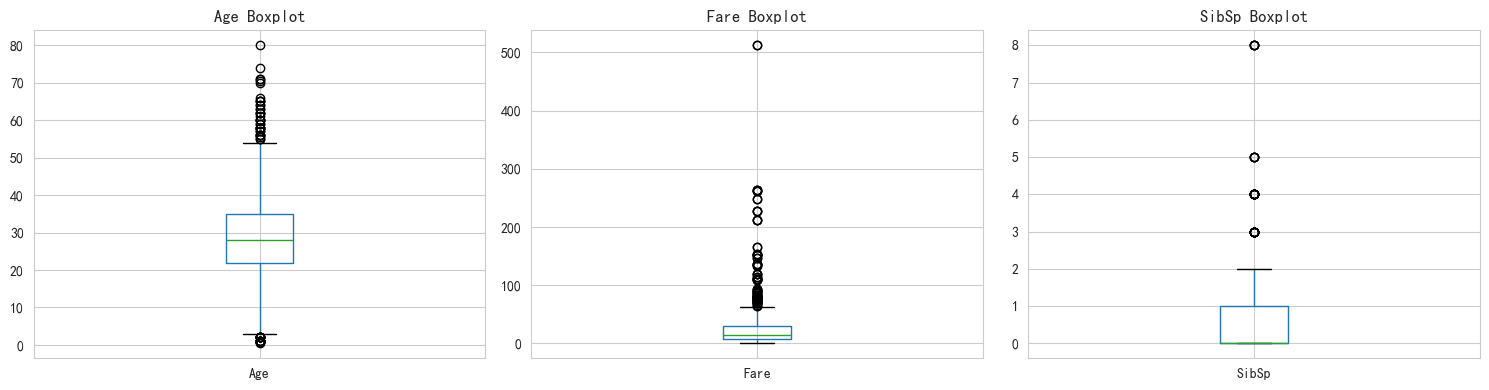

Fare: Q1=7.9, Q3=30.5, IQR=22.6
  合理范围：[0.0, 64.4]
  异常值数量：93 (13.1%)


In [5]:
'''单元4'''
# 数据预处理
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style("whitegrid")

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 从网络读取泰坦尼克号数据集
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 查看数据概览
print("数据集形状：", df.shape)
print("\n数据类型与缺失值情况：")
print(df.info())

# 数据集划分
from sklearn.model_selection import train_test_split

# 定义特征 X 和 目标标签 y (Survived)
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 21,
    stratify = y
)

print(f"\n训练集：{X_train.shape[0]} 样本")
print(f"测试集：{X_test.shape[0]} 样本")
print(f"\n训练集存活率：{y_train.mean():.2%}")
print(f"测试集存活率：{y_test.mean():.2%}")

# EDA 缺失值统计
missing = X_train.isnull().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
missing_df = pd.DataFrame({
    "缺失数": missing,
    "缺失率": missing_pct
}).query("缺失数 > 0")

print("\n", missing_df)

# 数据清洗
duplicates = X_train.duplicated().sum()
print(f"\n重复行数：{duplicates}")
# 若有重复行
if duplicates > 0:
    X_train = X_train.drop_duplicates()
    y_train = y_train[X_train.index]

# 处理缺失值
from sklearn.impute import SimpleImputer

# Age：中位数填充
age_imputer = SimpleImputer(strategy='median')
age_imputer.fit(X_train[['Age']]) # fit 只用训练集！
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age']  = age_imputer.transform(X_test[['Age']]).ravel() # 用训练集的中位数！

# — Embarked：众数填充（只缺 2 个） —
embarked_imputer = SimpleImputer(strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked']  = embarked_imputer.transform(X_test[['Embarked']]).ravel()

# — Cabin：缺失 77%，先转化为"有无客舱信息"，再删除原列 —
X_train['HasCabin'] = X_train['Cabin'].notna().astype(int)
X_test['HasCabin']  = X_test['Cabin'].notna().astype(int)
X_train.drop(columns=['Cabin'], inplace=True)
X_test.drop(columns=['Cabin'], inplace=True)

# 异常值检测
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    X_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

# 异常值处理
def detect_outliers_iqr(data, column, factor=1.5):
    # 计算四分位数
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = max(0, Q1 - factor * IQR)
    upper = Q3 + factor * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"{column}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  合理范围：[{lower:.1f}, {upper:.1f}]")
    print(f"  异常值数量：{len(outliers)} ({len(outliers)/len(data):.1%})")
    return lower, upper

# 调用IQR异常检测函数处理票价特征
lower, upper = detect_outliers_iqr(X_train, 'Fare')

# 对于 Fare，我们选择截断而非删除
# 因为高票价可能是真实的，头等舱确实很贵
X_train['Fare'] = X_train['Fare'].clip(lower=lower, upper=upper)
X_test['Fare'] = X_test['Fare'].clip(lower=lower, upper=upper)

样本数: 20640, 特征数: 8
房价范围: [0.15, 5.00], 均值: 2.07
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25   

训练集：16512 样本
测试集：4128 样本

前10组【真实值 vs 预测值】：
真实值：0.48,	预测值：0.72
真实值：0.46,	预测值：1.76
真实值：5.00,	预测值：2.71
真实值：2.19,	预测值：2.84
真实值：2.78,	预测值：2.60
真实值：1.59,	预测值：2.01
真实值：1.98,	预测值：2.65
真实值：1.57,	预测值：2.17
真实值：3.40,	预测值：2.74
真实值：4.47,	预测值：3.92

===== 线性回归评估指标 =====
MAE: 	0.5332
MSE: 	0.5559
RMSE: 	0.7456
R²: 	0.5758  (解释了 57.6% 的方差)

===== 5折交叉验证RMSE =====
Fold 1: 0.6963
Fold 2: 0.7890
Fold 3: 0.8039
Fold 4: 0

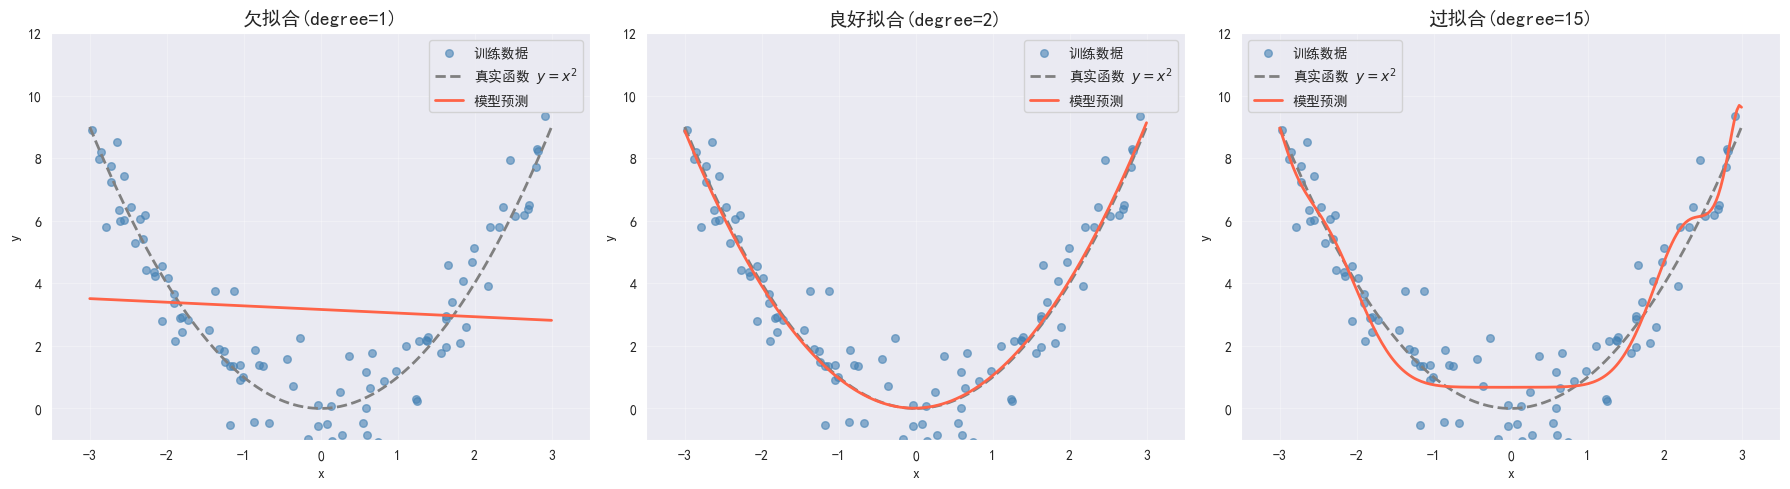

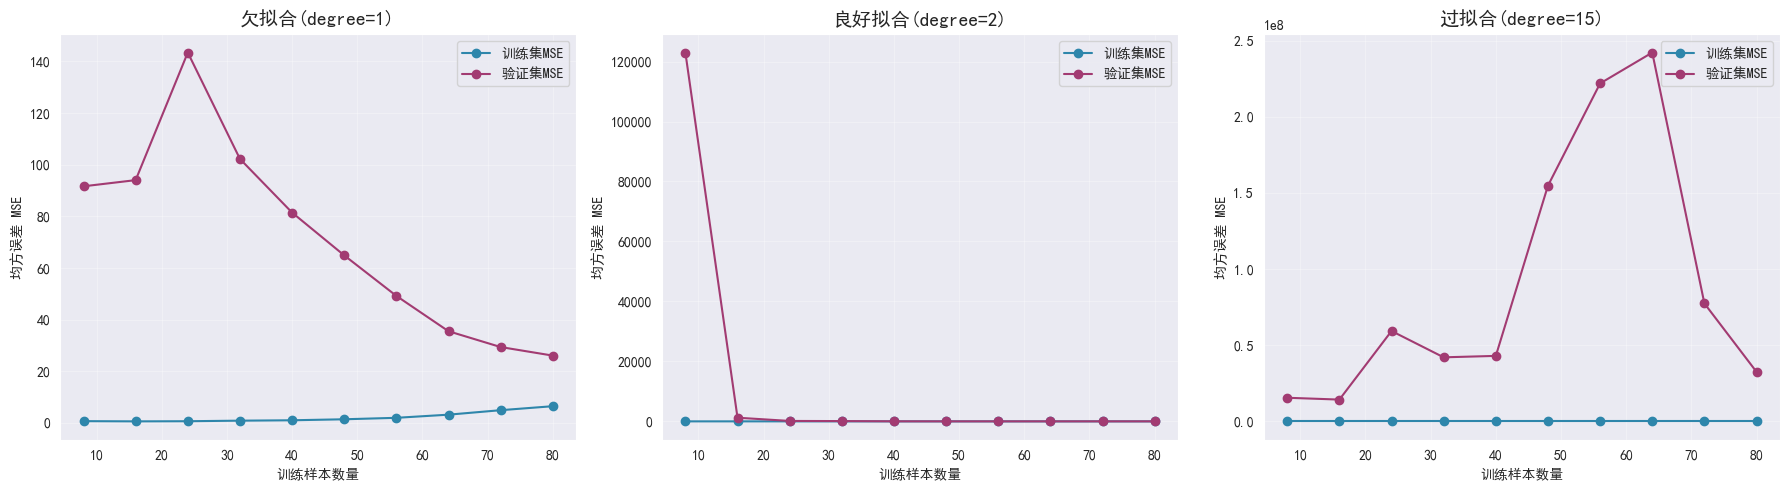

===== 加州房价：多模型对比 R² =====
              模型  训练 R²  测试 R²  R²差值(过拟合参考)
            线性回归 0.6126 0.5758       0.0368
决策树(max_depth=5) 0.6377 0.5997       0.0379
     随机森林(100棵树) 0.8719 0.7737       0.0982

===== 正则化对比：普通线性回归/Ridge/Lasso =====


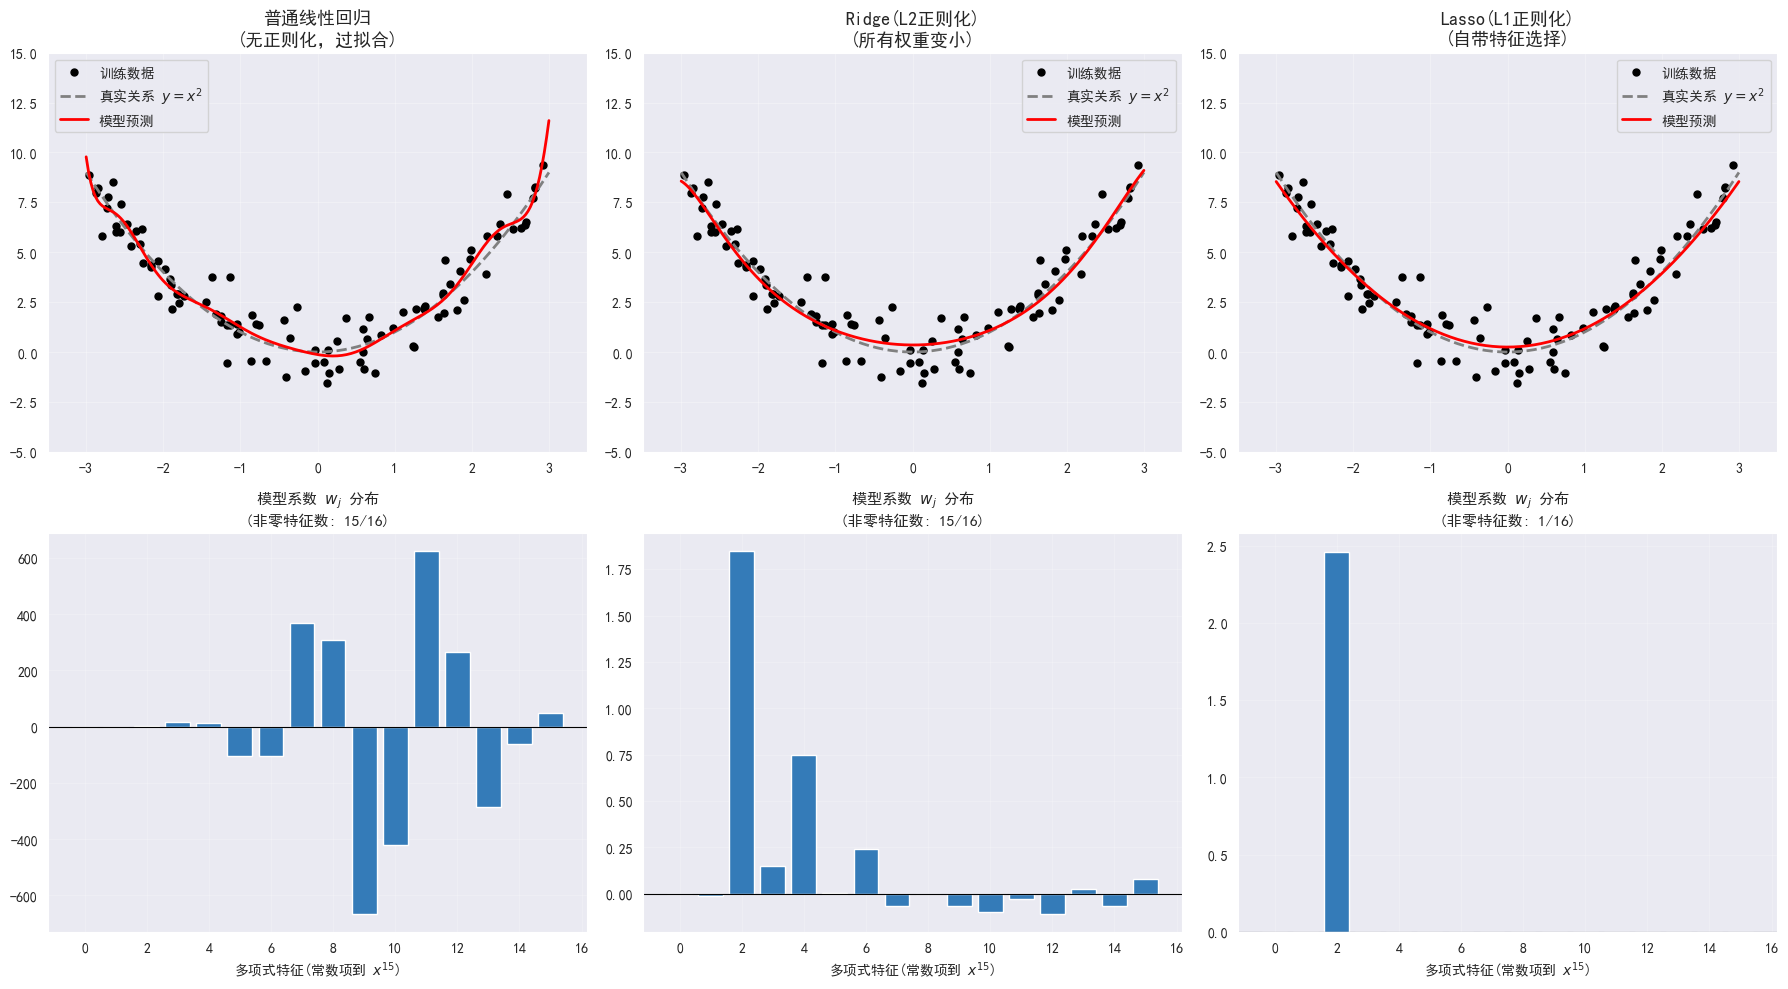

          模型   训练R²
      普通线性回归 0.9056
Ridge(L2正则化) 0.8906
Lasso(L1正则化) 0.8906


In [14]:
'''单元5'''
# ========== 导入库（统一放最上方，消除重复import） ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# =================================================================
# 第一部分：加州房价 线性回归基线模型、评估指标、5折交叉验证
# =================================================================
# 加载数据
housing = fetch_california_housing()
X_raw = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # 房价中位数 (单位: 10万美元)

print(f"样本数: {X_raw.shape[0]}, 特征数: {X_raw.shape[1]}")
print(f"房价范围: [{y.min():.2f}, {y.max():.2f}], 均值: {y.mean():.2f}")
print(X_raw.head(), "\n")

# 标准化 + 划分数据集
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"训练集：{X_train.shape[0]} 样本")
print(f"测试集：{X_test.shape[0]} 样本\n")

# 训练 baseline 线性回归
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("前10组【真实值 vs 预测值】：")
for i in range(10):
    print(f"真实值：{y_test[i]:.2f},\t预测值：{y_pred[i]:.2f}")

# 回归评估指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== 线性回归评估指标 =====")
print(f"MAE: \t{mae:.4f}")
print(f"MSE: \t{mse:.4f}")
print(f"RMSE: \t{rmse:.4f}")
print(f"R²: \t{r2:.4f}  (解释了 {r2*100:.1f}% 的方差)\n")

# K-Fold 交叉验证
scores = cross_val_score(
    LinearRegression(),
    X_scaled, y,
    cv=5,
    scoring='neg_mean_squared_error'
)
rmse_scores = np.sqrt(-scores)

print("===== 5折交叉验证RMSE =====")
for i, score in enumerate(rmse_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\n平均 RMSE: {rmse_scores.mean():.4f} ∓ {rmse_scores.std():.4f}\n")

# =================================================================
# 第二部分：抛物线模拟数据 —— 演示欠拟合/正常拟合/过拟合
# =================================================================
print("===== 绘制拟合曲线与学习曲线（模拟y=x²数据集）=====\n")
np.random.seed(42)
n_samples = 100
X_curve = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y_curve = X_curve.ravel() ** 2 + np.random.normal(0, 1, n_samples)

curve_models = {
    "欠拟合(degree=1)": make_pipeline(PolynomialFeatures(1), LinearRegression()),
    "良好拟合(degree=2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "过拟合(degree=15)": make_pipeline(PolynomialFeatures(15), LinearRegression())
}

# 绘制拟合效果图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
X_test_curve = np.linspace(-3, 3, 200).reshape(-1, 1)
for ax, (title, model) in zip(axes, curve_models.items()):
    model.fit(X_curve, y_curve)
    y_pred = model.predict(X_test_curve)
    ax.scatter(X_curve, y_curve, color='steelblue', s=30, alpha=0.6, label='训练数据')
    ax.plot(X_test_curve, X_test_curve.ravel()**2, '--', color='gray', linewidth=2, label='真实函数 $y = x^2$')
    ax.plot(X_test_curve, y_pred, '-', color='tomato', linewidth=2, label='模型预测')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1, 12)
plt.tight_layout()
plt.show()

# 绘制学习曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, model) in zip(axes, curve_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_curve, y_curve,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="neg_mean_squared_error",
        random_state=42
    )
    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)
    ax.plot(train_sizes, train_mse, 'o-', color="#2E86AB", label="训练集MSE")
    ax.plot(train_sizes, val_mse, 'o-', color="#A23B72", label="验证集MSE")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("训练样本数量")
    ax.set_ylabel("均方误差 MSE")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =================================================================
# 第三部分：增加模型复杂度以解决欠拟合问题
# =================================================================
print("===== 加州房价：多模型对比 R² =====")
compare_models = {
    "线性回归": make_pipeline(StandardScaler(), LinearRegression()),
    "决策树(max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "随机森林(100棵树)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

results = []
for name, model in compare_models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))
    results.append({
        "模型": name,
        "训练 R²": train_r2,
        "测试 R²": test_r2,
        "R²差值(过拟合参考)": train_r2 - test_r2
    })

df_result = pd.DataFrame(results)
print(df_result.to_string(index=False, float_format="%.4f"))

# =================================================================
# 第四部分：使用正则化以解决过拟合问题（匹配你截图效果图）
# =================================================================
print("\n===== 正则化对比：普通线性回归/Ridge/Lasso =====")
degree = 15

models = {
    "普通线性回归\n(无正则化，过拟合)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), LinearRegression()
    ),
    "Ridge(L2正则化)\n(所有权重变小)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=5.0)
    ),
    "Lasso(L1正则化)\n(自带特征选择)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=0.2, max_iter=20000)
    )
}

# 创建画布：2行3列（上：拟合曲线，下：系数分布）
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
X_line = np.linspace(-3, 3, 200).reshape(-1, 1)

for idx, (title, model) in enumerate(models.items()):
    ax_curve = axes[0, idx]   # 第一行：拟合曲线
    ax_coef  = axes[1, idx]   # 第二行：系数柱状图

    # 训练模型
    model.fit(X_curve, y_curve)
    y_pred = model.predict(X_line)

    # 1. 绘制拟合曲线
    ax_curve.scatter(X_curve, y_curve, c="black", s=25, label="训练数据")
    ax_curve.plot(X_line, X_line.ravel()**2, "--", c="gray", lw=2, label="真实关系 $y=x^2$")
    ax_curve.plot(X_line, y_pred, "-", c="red", lw=2, label="模型预测")
    ax_curve.set_title(title, fontsize=13)
    ax_curve.set_xlim(-3.5, 3.5)
    ax_curve.set_ylim(-5, 15)
    ax_curve.legend()
    ax_curve.grid(True, alpha=0.3)

    # 2. 提取系数
    estimator_name = model.steps[-1][0]
    coefs = model.named_steps[estimator_name].coef_
    non_zero = np.sum(np.abs(coefs) > 1e-5)

    # 绘制系数柱状图
    ax_coef.bar(range(len(coefs)), coefs, color="#347bb8")
    ax_coef.set_title(f"模型系数 $w_j$ 分布\n(非零特征数: {non_zero}/{len(coefs)})", fontsize=11)
    ax_coef.set_xlabel("多项式特征(常数项到 $x^{15}$)")
    ax_coef.axhline(y=0, color="black", lw=0.8)
    ax_coef.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 打印指标对比
reg_result = []
for name, model in models.items():
    model.fit(X_curve, y_curve)
    train_r2 = r2_score(y_curve, model.predict(X_curve))
    reg_result.append({
        "模型": name.split("\n")[0],
        "训练R²": train_r2
    })
print(pd.DataFrame(reg_result).to_string(index=False, float_format="%.4f"))

训练集准确率：0.9890
测试集准确率：0.9825

==== 分类评估 ====
混淆矩阵：
[[41  1]
 [ 1 71]]

分类报告：
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



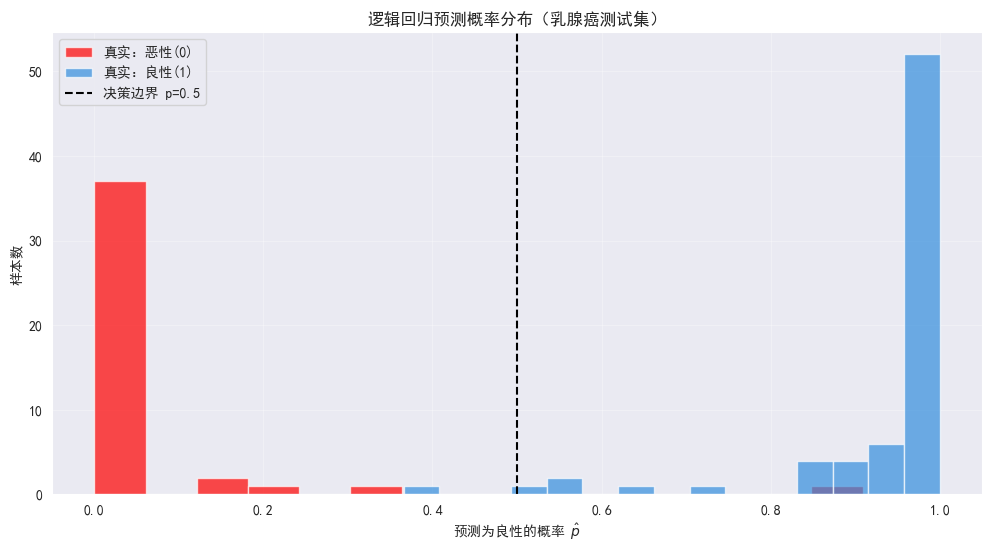

In [7]:
'''单元6'''
"""
乳腺癌数据集，目标：二分类——恶性(0)/良性(1)
"""
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 加载乳腺癌数据集
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0恶性，1良性

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 训练逻辑回归
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 准确率输出
train_acc = model.score(X_train_scaled, y_train)
test_acc  = model.score(X_test_scaled, y_test)
print(f"训练集准确率：{train_acc:.4f}")
print(f"测试集准确率：{test_acc:.4f}")

# 混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test_scaled)
print("\n==== 分类评估 ====")
print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred))

# ========= 预测概率可视化核心代码 =========
y_proba = model.predict_proba(X_test_scaled)[:, 1]
proba_malign = y_proba[y_test == 0]   # 红色：恶性
proba_benign = y_proba[y_test == 1]   # 蓝色：良性

plt.figure(figsize=(12, 6))
plt.hist(proba_malign, bins=15, alpha=0.7, color='red', label='真实：恶性(0)')
plt.hist(proba_benign, bins=15, alpha=0.7, color='#348ede', label='真实：良性(1)')

plt.axvline(x=0.5, linestyle='--', color='black', label='决策边界 p=0.5')
plt.xlabel(r"预测为良性的概率 $\hat{p}$")
plt.ylabel("样本数")
plt.title("逻辑回归预测概率分布（乳腺癌测试集）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 结果分析
- 数据集共 569 个样本、30个特征
- 特征值量级差异很大，**必须标准化**后再训练
- 测试集准确率高达 **98.25%**，模型具备良好的泛化能力
- 说明乳腺癌特征与标签之间存在较强的线性可分性

红色（恶性）集中在0附近，蓝色（良性）集中在1附近。
两组分布几乎不重叠，中间极少数样本落在决策边界（p=0.5）附近，说明模型区分能力很强。

========== 1. 数据集前5行预览 ==========
   花萼长度(cm)  花萼宽度(cm)  花瓣长度(cm)  花瓣宽度(cm) 最终分类结果
0       5.1       3.5       1.4       0.2    山鸢尾
1       4.9       3.0       1.4       0.2    山鸢尾
2       4.7       3.2       1.3       0.2    山鸢尾
3       4.6       3.1       1.5       0.2    山鸢尾
4       5.0       3.6       1.4       0.2    山鸢尾

========== 2. 数据集包含的分类及数量 ==========
最终分类结果
山鸢尾       50
变色鸢尾      50
维吉尼亚鸢尾    50
Name: count, dtype: int64

决策树模型的预测准确率为：100.00%



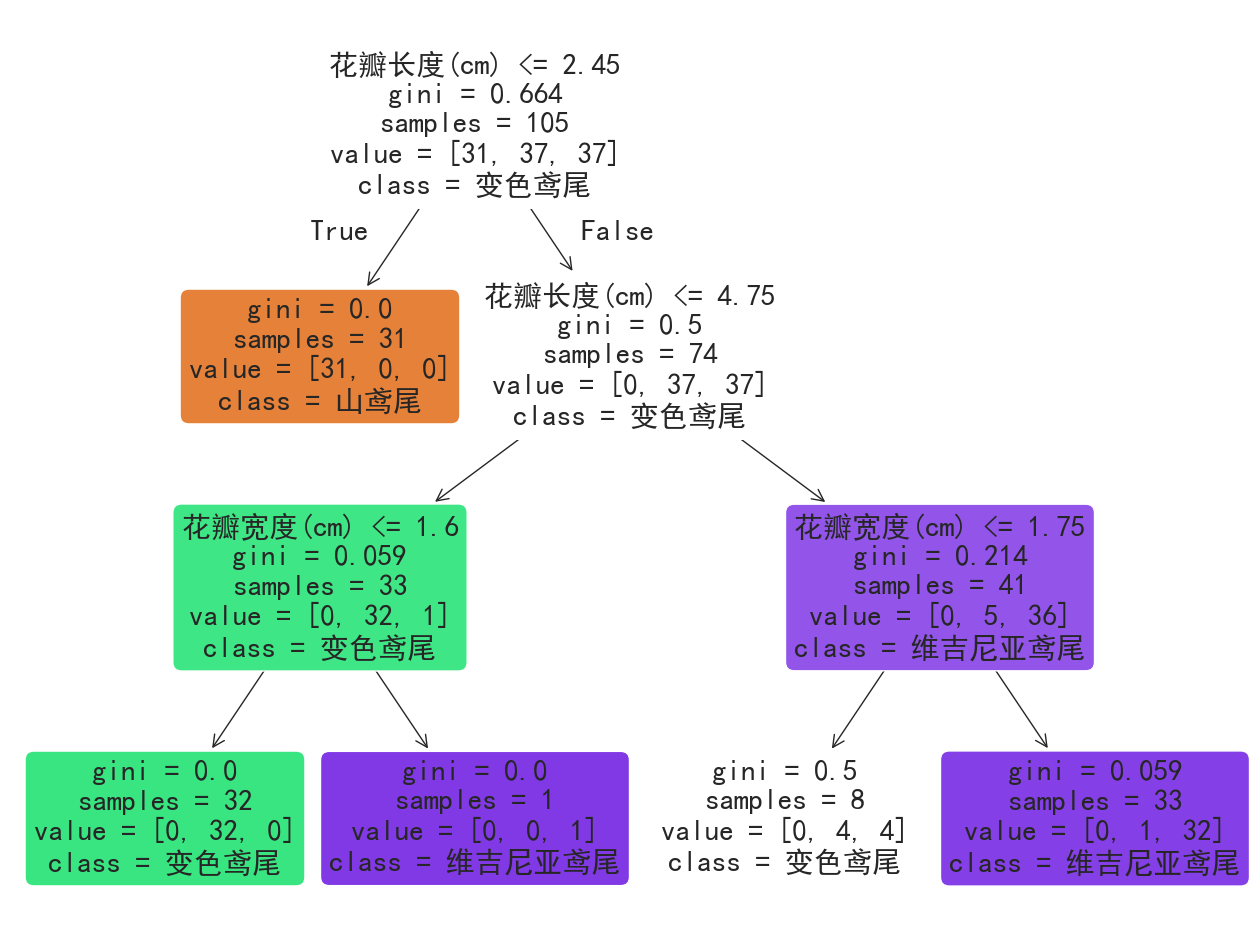

In [15]:
'''单元7'''
"""
鸢尾花数据集（150朵花，4个特征，3个品种）
"""
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

# 1）、加载数据集
iris = load_iris()
# 2）、将特征名翻译为中文
feature_names_cn = ['花萼长度(cm)', '花萼宽度(cm)', '花瓣长度(cm)', '花瓣宽度(cm)']
target_names_cn = ['山鸢尾', '变色鸢尾', '维吉尼亚鸢尾']
# 3）、转换成表格(DataFrame)形式展出
df = pd.DataFrame(iris.data, columns=feature_names_cn)
df['最终分类结果'] = [target_names_cn[i] for i in iris.target]

print("========== 1. 数据集前5行预览 ==========")
print(df.head())
print("\n========== 2. 数据集包含的分类及数量 ==========")
print(df['最终分类结果'].value_counts())

# 1、划分数据（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

# 2、构建与训练模型（使用基尼系数，最大深度为3）
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42) # 最大深度为6，过拟合了
clf.fit(X_train, y_train)

# 3、预测成绩
y_pred = clf.predict(X_test)
print(f"\n决策树模型的预测准确率为：{accuracy_score(y_test, y_pred)*100:.2f}%\n")

# 4、画出决策树
plt.figure(figsize=(16,12))
tree.plot_tree(clf, feature_names=feature_names_cn, class_names=target_names_cn, filled=True, rounded=True)
plt.show()

节点信息解读
- samples: 节点包含的总样本数
- value: 各类别样本分布
- gini: 基尼不纯度（0表示完全纯净）
- class: 当前节点的默认类别

通过可视化，我们可以清晰地看到模型是如何一步步通过***花瓣长度***和***花瓣宽度***来将3种鸢尾花区分开的。

测试集准确率：1.0000
OOB袋外得分：0.9429


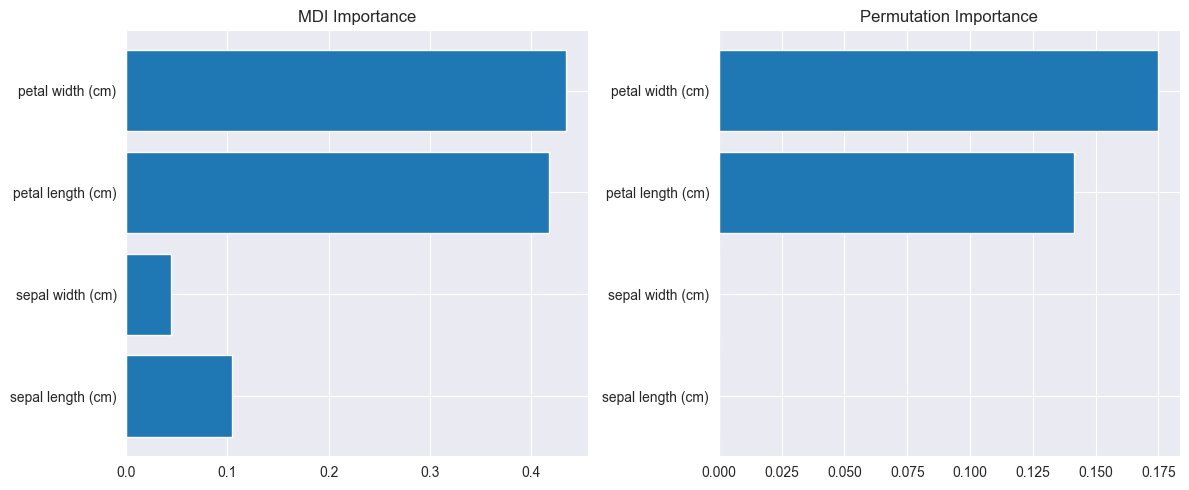

In [1]:
'''单元8'''
"""
使用 100 棵决策树组成随机森林，对鸢尾花数据集做训练与验证
"""
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# 加载数据集
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 构建随机森林
rf = RandomForestClassifier(
    n_estimators=100,        # 决策树数量
    max_features="sqrt",     # 分裂时随机选取特征数量
    oob_score=True,          # 开启袋外样本评估（OOB）
    random_state=42,
    n_jobs=-1                # 使用全部CPU并行训练
)

# 训练模型
rf.fit(X_train, y_train)

# 预测与评估
y_pred = rf.predict(X_test)
print(f"测试集准确率：{accuracy_score(y_test, y_pred):.4f}")
print(f"OOB袋外得分：{rf.oob_score_:.4f}")

#======== 特征重要性 =========
feature_names = load_iris().feature_names
# 基于不纯度
importances = rf.feature_importances_
# 基于排列
perm_imp = permutation_importance(
    rf, X_test, y_test, n_repeats=30
)
# 绘制对比图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(feature_names, importances)
axes[0].set_title('MDI Importance')

axes[1].barh(feature_names, perm_imp.importances_mean)
axes[1].set_title('Permutation Importance')

plt.tight_layout()
plt.show()

测试集准确率 100%：得益于鸢尾花数据集较小且特征明显
OOB准确率0.9429：模型仅利用训练中产生的袋外数据，就达到了 94% 的准确率

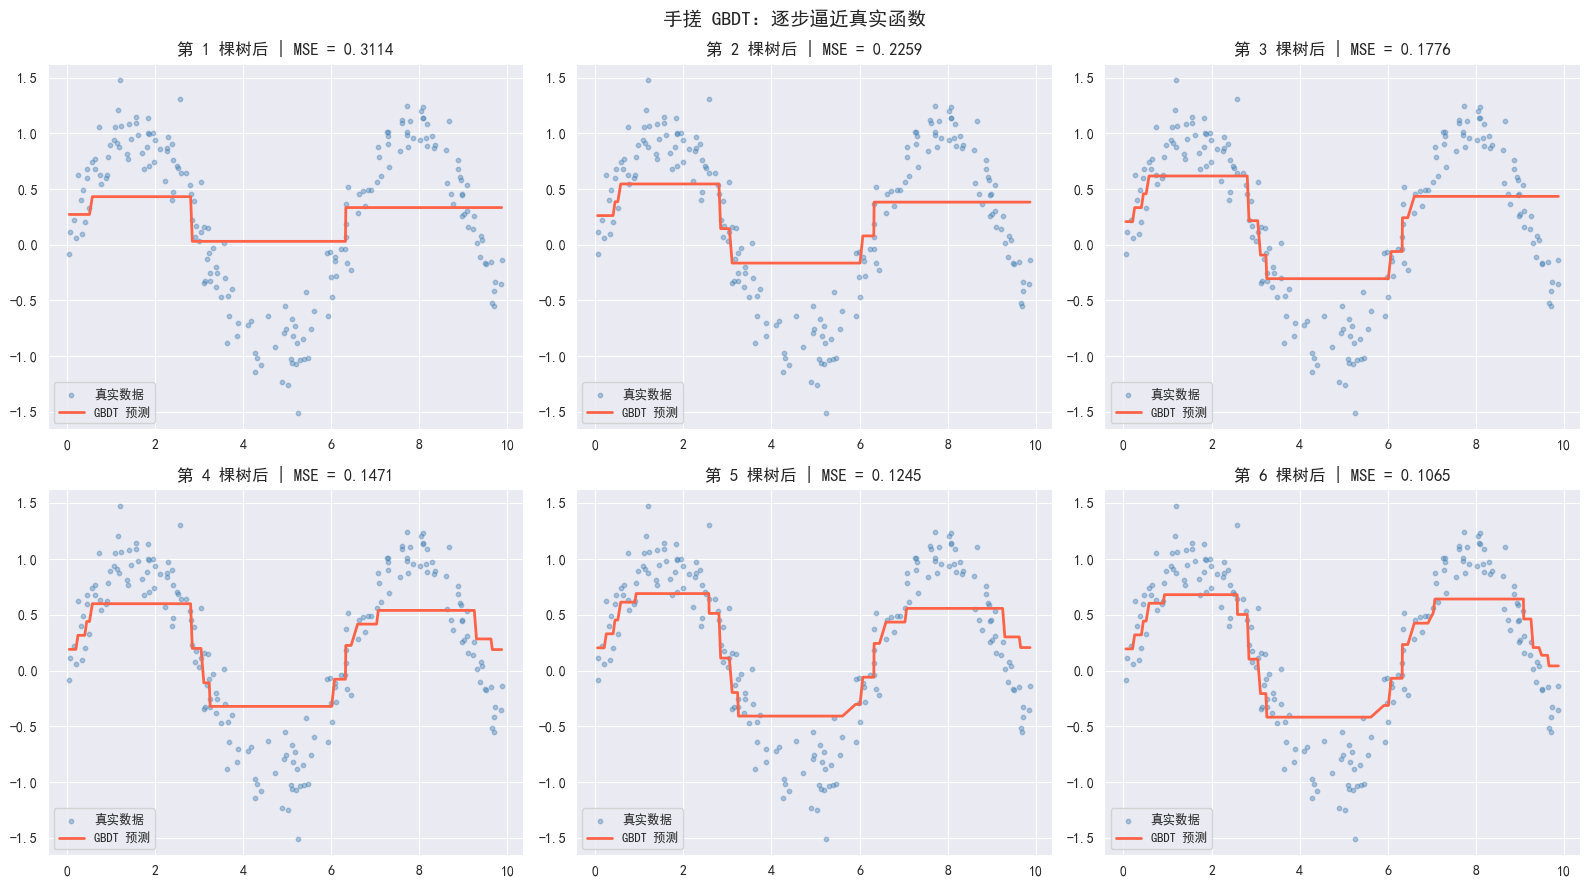

训练集大小：(16512, 8)
测试集大小：(4128, 8)
特征：['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

指标                   随机森林      XGBoost
MSE                   0.2952       0.2152
R² Score              0.7747       0.8358
训练时间                 1.05         0.15
[0]	validation_0-rmse:1.11287
[50]	validation_0-rmse:0.57870
[100]	validation_0-rmse:0.51626
[150]	validation_0-rmse:0.49373
[200]	validation_0-rmse:0.48203
[250]	validation_0-rmse:0.47370
[300]	validation_0-rmse:0.46779
[350]	validation_0-rmse:0.46332
[400]	validation_0-rmse:0.46061
[450]	validation_0-rmse:0.45773
[500]	validation_0-rmse:0.45559
[550]	validation_0-rmse:0.45410
[600]	validation_0-rmse:0.45191
[650]	validation_0-rmse:0.45060
[700]	validation_0-rmse:0.44904
[750]	validation_0-rmse:0.44720
[800]	validation_0-rmse:0.44614
[850]	validation_0-rmse:0.44483
[900]	validation_0-rmse:0.44353
[950]	validation_0-rmse:0.44264
[1000]	validation_0-rmse:0.44200
[1050]	validation_0-rmse:0.44104

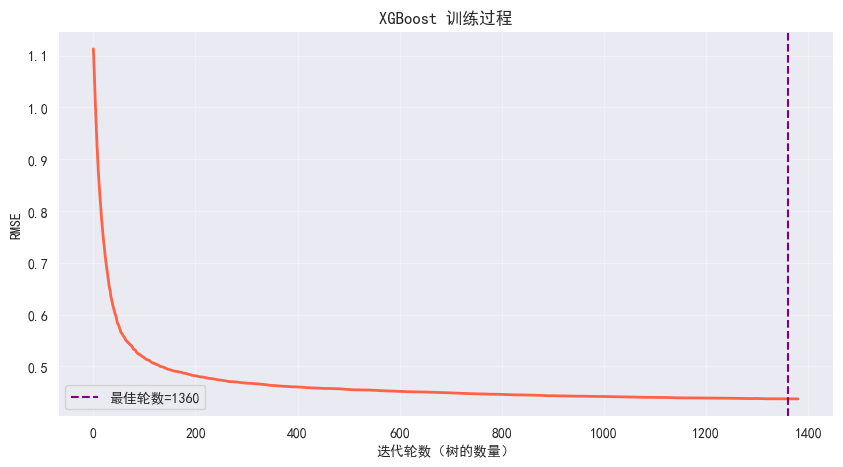

In [16]:
'''单元9'''
"""
手搓 GBDT：代码实现
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 生成带噪声的正弦曲线数据
np.random.seed(42)
X = np.sort(np.random.rand(200, 1)*10, axis=0)
y = np.sin(X).ravel() + np.random.randn(200) * 0.2

n_trees = 6
learning_rate = 0.3
trees = []
F = np.full_like(y, y.mean()) # 步骤1：用均值初始化

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i in range(n_trees):
    # 计算残差（MSE下的负梯度）
    residual = y - F

    # 用一棵浅树拟合残差
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residual)
    pred = tree.predict(X)
    trees.append(tree)

    # 更新模型
    F += learning_rate * pred

    # 可视化
    mse = np.mean((y - F) ** 2)
    ax = axes[i // 3][i % 3]
    ax.scatter(X, y, s=10, alpha=0.4, color='steelblue', label='真实数据')
    ax.plot(X, F, color='tomato', linewidth=2, label=f'GBDT 预测')
    ax.set_title(f'第 {i+1} 棵树后 | MSE = {mse:.4f}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('手搓 GBDT：逐步逼近真实函数', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#========== 使用 XGBoost 预测加州房价 ==========
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

# 加载加州房价数据集
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")
print(f"特征：{feature_names}")

#========== 随机森林 ==========
start = time.time()
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_time = time.time() - start
rf_pred = rf.predict(X_test)

#========== XGBoost ==========
start = time.time()
xgb = XGBRegressor(
    n_estimators=200,       # 决策树数量
    max_depth=5,            # 每棵树的最大深度
    learning_rate=0.1,      # 学习率
    subsample=0.8,          # 每次训练用多少比例的样本
    colsample_bytree=0.8,   # 每次训练用多少比例的特征
    random_state=42,        # 固定随机种子
    n_jobs=-1               # 用满CPU核心加速
)
xgb.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_pred = xgb.predict(X_test)

# 结果对比
print()
print("=" * 50)
print(f"{'指标':<12} {'随机森林':>12} {'XGBoost':>12}")
print("=" * 50)
print(f"{'MSE':<15} {mean_squared_error(y_test, rf_pred):>12.4f} {mean_squared_error(y_test, xgb_pred):>12.4f}")
print(f"{'R² Score':<15} {r2_score(y_test, rf_pred):>12.4f} {r2_score(y_test, xgb_pred):>12.4f}")
print(f"{'训练时间':<12} {rf_time:>12.2f} {xgb_time:>12.2f}")

# Early Stopping 防止过拟合【修复版本】
xgb_es = XGBRegressor(
    n_estimators=10000,         # 最大决策树数量（上限）
    max_depth=5,                # 每棵树的最大深度
    learning_rate=0.05,         # 学习率
    subsample=0.8,              # 样本采样比例
    colsample_bytree=0.8,       # 特征采样比例
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=20
)

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_es_pred = xgb_es.predict(X_test)
print(f"\n最佳迭代轮数：{xgb_es.best_iteration}")
print(f"最佳MSE：{mean_squared_error(y_test, xgb_es_pred):.4f}")

# 可视化 Early Stopping 训练过程
results = xgb_es.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['rmse'], color='tomato', linewidth=2)
plt.xlabel('迭代轮数（树的数量）')
plt.ylabel('RMSE')
plt.title('XGBoost 训练过程')
plt.axvline(x=xgb_es.best_iteration, color='purple', linestyle='--', label=f'最佳轮数={xgb_es.best_iteration}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

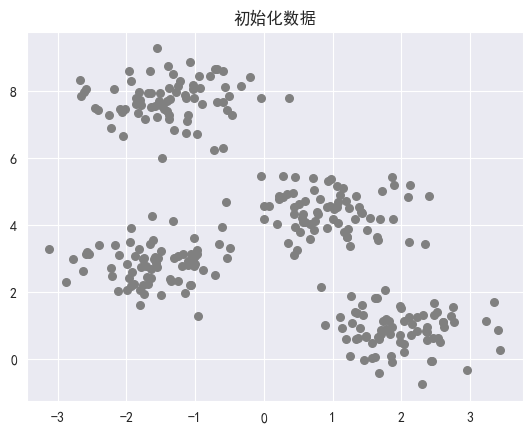

算法在第 10 次迭代后完全收敛！中心点不再移动。
SSE: 362.47
迭代次数: 3


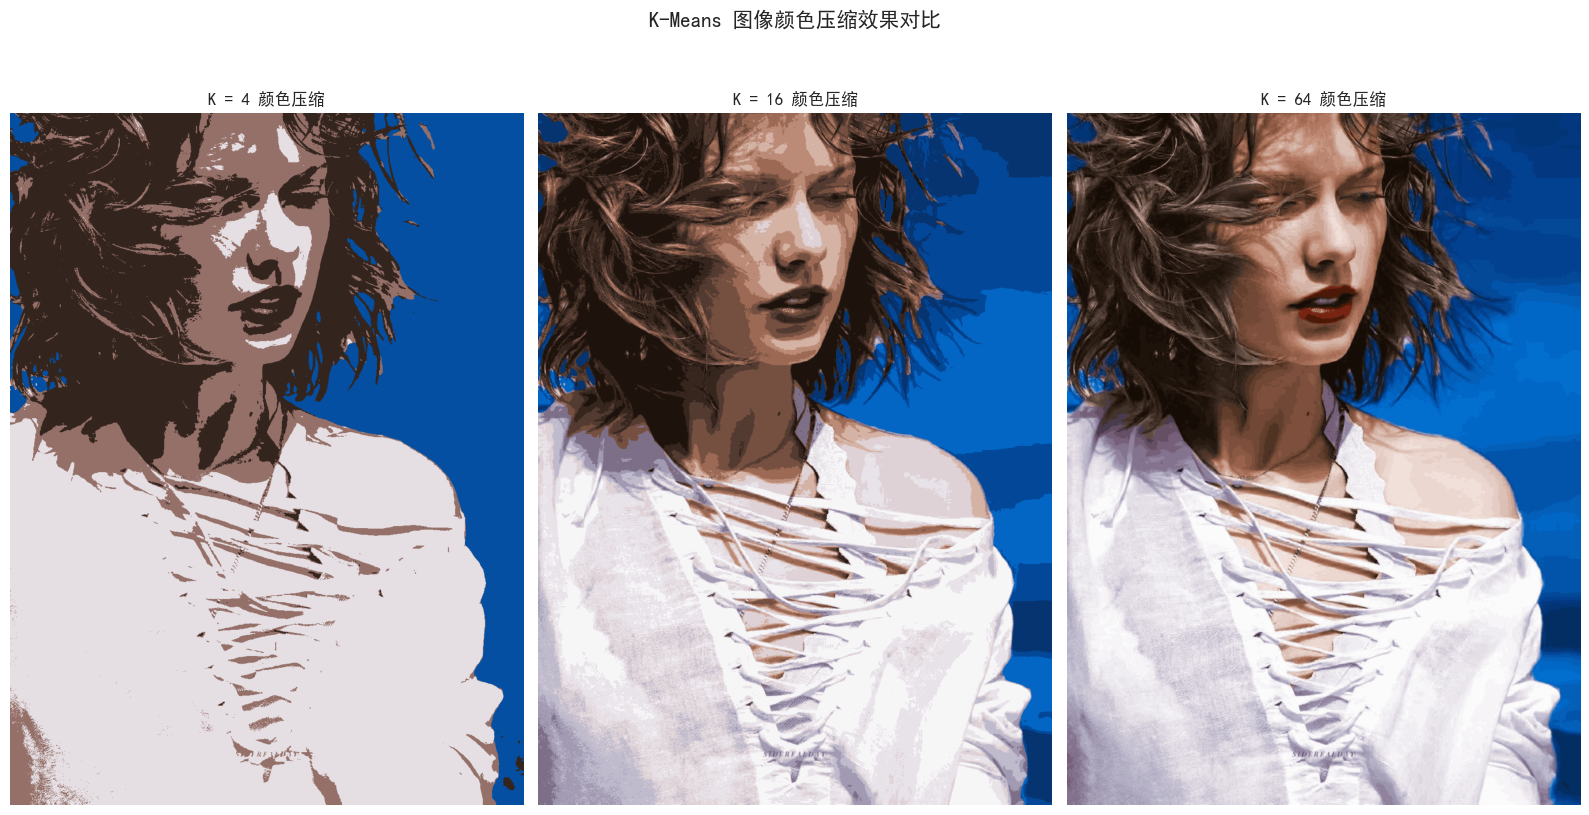

In [21]:
'''单元10'''
"""
K-Means 聚类
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 生成 300 个样本，分为 4 个簇
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)
# 样本分布可视化
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("初始化数据")
plt.show()


#========== 实践 ==========
from scipy.spatial.distance import cdist

k = 4
# 随机选择 k 个点作为初始中心
initial_indices = np.random.choice(X.shape[0], k, replace=False)
centroids = X[initial_indices]

max_iters = 15
for i in range(max_iters):
    # 步骤1：分配(Assignment)
    distances = cdist(X, centroids)         # 计算 每个样本点 到 每个中心点 的距离
    labels = np.argmin(distances, axis=1)   # 对每一行（每个点）找最小值

    # 步骤2：更新(Update)
    new_centroids = np.array([X[labels==j].mean(axis=0) for j in range(k)])

    # 检测收敛
    if np.all(centroids == new_centroids):
        print(f"算法在第 {i+1} 次迭代后完全收敛！中心点不再移动。")
        break

    centroids = new_centroids

#========== 二维数据聚类可视化演示 ==========
"""
结合 K-Means++ 和 肘部法则 优化，用 scikit-learn 演示完整过程
"""
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1.生成模拟数据，300 个样本，4 个天然簇
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# 2.运行 K-Means
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,  # 迭代次数
    random_state=42
)
y_pred = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_ # 获取质心

print(f"SSE: {kmeans.inertia_:.2f}")
print(f"迭代次数: {kmeans.n_iter_}")

"""
实战应用：图像颜色压缩（代码）
"""
from skimage import io

# 1. 读取图片并预处理
image = io.imread("C:\\Users\\30869\\OneDrive\\画像\\Taylor.jpg")
image = image / 255.0             # RGB归一化 [0, 255] → [0,1]
h, w, c = image.shape             # h高，w宽，c通道数(3=RGB)
pixels = image.reshape(-1, 3)     # 展平：(h,w,3) → (h*w, 3)，每一行代表1个像素的RGB

# 2. 对不同K值执行颜色压缩
plt.figure(figsize=(16,9))
k_list = [4, 16, 64]
for idx, k in enumerate(k_list):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(pixels)

    # 使用聚类中心还原像素颜色
    centers = km.cluster_centers_
    compressed_pixels = centers[labels]
    compressed_img = compressed_pixels.reshape(h, w, 3)

    # 绘图展示
    plt.subplot(1, 3, idx+1)
    plt.imshow(compressed_img)
    plt.title(f'K = {k} 颜色压缩')
    plt.axis('off')

plt.suptitle("K-Means 图像颜色压缩效果对比", fontsize=15)
plt.tight_layout()
plt.show()

原始数据维度：(150, 4)

特征相关系数矩阵：
[[ 1.    -0.118  0.872  0.818]
 [-0.118  1.    -0.428 -0.366]
 [ 0.872 -0.428  1.     0.963]
 [ 0.818 -0.366  0.963  1.   ]]

各主成分特征值（方差）： [2.9381 0.9202 0.1477 0.0209]
各主成分方差解释比：     [0.7296 0.2285 0.0367 0.0052]
累积方差解释比：       [0.7296 0.9581 0.9948 1.    ]

主成分载荷矩阵（每列是一个主成分方向）：
  sepal length (cm)             : PC1=+0.521  PC2=+0.377
  sepal width (cm)              : PC1=-0.269  PC2=+0.923
  petal length (cm)             : PC1=+0.580  PC2=+0.024
  petal width (cm)              : PC1=+0.565  PC2=+0.067


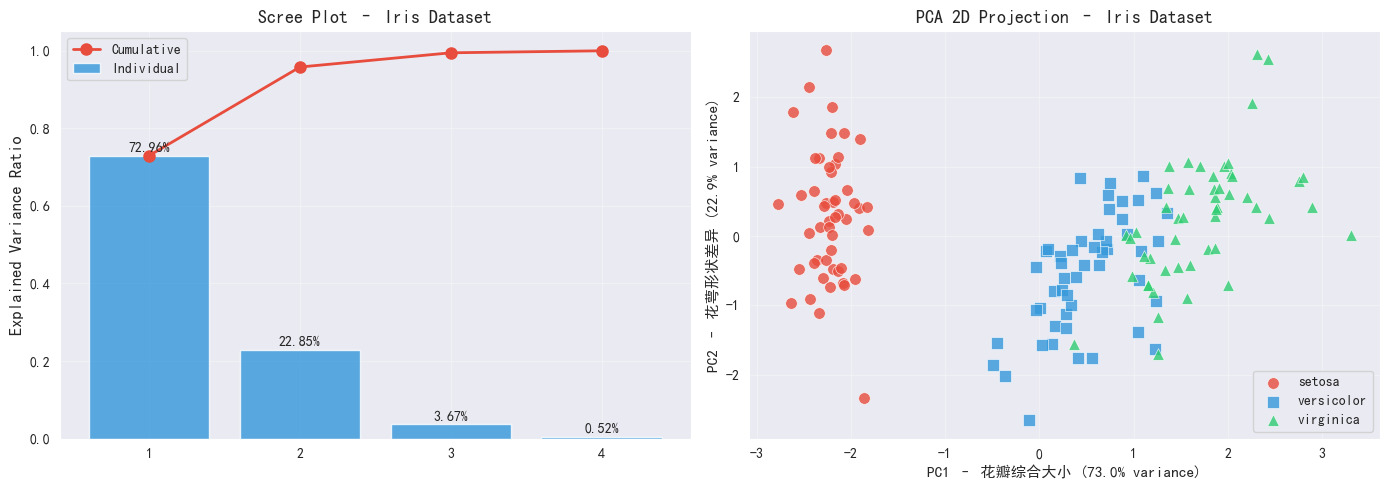

In [1]:
'''单元10'''
"""
鸢尾花 PCA 分析实战
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

#========== 加载数据 ==========
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names
feature_names = iris.feature_names
print(f"原始数据维度：{X.shape}") # (150, 4)

#========== 标准化 ==========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#========== 分析特征相关性 ==========
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
print("\n特征相关系数矩阵：")
print(np.round(corr_matrix, 3))

#========== PCA 降维 ==========
pca = PCA()
pca.fit(X_scaled)
print("\n各主成分特征值（方差）：", np.round(pca.explained_variance_, 4))
print("各主成分方差解释比：    ", np.round(pca.explained_variance_ratio_, 4))
print("累积方差解释比：      ", np.round(np.cumsum(pca.explained_variance_ratio_), 4))

# 输出主成分载荷（特征向量），理解每个主成分的含义
print("\n主成分载荷矩阵（每列是一个主成分方向）：")
loadings = pca.components_.T
for i, fname in enumerate(feature_names):
    print(f"  {fname:30s}: PC1={loadings[i,0]:+.3f}  PC2={loadings[i,1]:+.3f}")

# 降到 2维
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

#========== 可视化 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：碎石图 ---
components = range(1, 5)
axes[0].bar(components, pca.explained_variance_ratio_,
        color='#3498db', alpha=0.8, label='Individual')
axes[0].plot(components, np.cumsum(pca.explained_variance_ratio_),
        'o-', color='#e74c3c', linewidth=2, markersize=8, label='Cumulative')

axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot – Iris Dataset', fontsize=13)
axes[0].set_xticks(components)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 标注每个柱子的值
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i + 1, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)

# --- 右图：2D 投影散点图 ---
colors = ['#e74c3c', '#3498db', '#2ecc71']
markers = ['o', 's', '^']
for i, (color, marker, name) in enumerate(zip(colors, markers, target_names)):
    mask = y == i
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, marker=marker, label=name,
                    alpha=0.8, edgecolors='w', s=70, linewidths=0.5)

axes[1].set_xlabel(
    f'PC1 – 花瓣综合大小 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
    fontsize=11)
axes[1].set_ylabel(
    f'PC2 – 花萼形状差异 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)',
    fontsize=11)
axes[1].set_title('PCA 2D Projection – Iris Dataset', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()